# 05 — Interpretabilidad y Conclusiones

**Reto 2 — IA avanzada en Business Analytics | Odisea Data**

**Objetivo:** Entender qué variables influyen más en la predicción, extraer insights de negocio y preparar el material para el informe y la presentación final.

**Técnicas de interpretabilidad:**
1. **Feature importance** de modelos basados en árboles.
2. **SHAP** (SHapley Additive exPlanations) — valores de contribución individuales.

**Resultado esperado:** Recomendaciones de negocio accionables basadas en los patrones detectados.

In [1]:
# ============================================================
# SETUP: carpetas + subida de archivos necesarios
# ============================================================
import os
import shutil
from google.colab import files

for c in ["outputs/charts", "outputs/metrics", "models/trained"]:
    os.makedirs(c, exist_ok=True)

# Archivos necesarios
archivos_necesarios = {
    "train_processed.csv": "data_processed",  # solo necesitamos X, la referencia es la raíz
    "test_processed.csv": "data_processed",
    "xgboost.pkl": "models/trained/xgboost.pkl",
    "lightgbm.pkl": "models/trained/lightgbm.pkl",
    "random_forest.pkl": "models/trained/random_forest.pkl",
}

faltantes = [f for f, _ in archivos_necesarios.items() if not os.path.exists(f)]
if faltantes:
    print("⚠️  Sube los siguientes archivos (todos a la vez con Ctrl):")
    for f in faltantes:
        print(f"   - {f}")
    files.upload()

# Mover modelos a su sitio
for f, destino in archivos_necesarios.items():
    if "/" in destino and os.path.exists(f) and not os.path.exists(destino):
        shutil.move(f, destino)

# Verificar
for f, destino in archivos_necesarios.items():
    ruta = destino if "/" in destino else f
    estado = "✅" if os.path.exists(ruta) else "❌"
    print(f"{estado} {ruta}")

⚠️  Sube los siguientes archivos (todos a la vez con Ctrl):
   - train_processed.csv
   - test_processed.csv
   - xgboost.pkl
   - lightgbm.pkl
   - random_forest.pkl


Saving test_processed.csv to test_processed.csv
Saving train_processed.csv to train_processed.csv
✅ train_processed.csv
✅ test_processed.csv
✅ models/trained/xgboost.pkl
✅ models/trained/lightgbm.pkl
✅ models/trained/random_forest.pkl


In [2]:
# ============================================================
# IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

import shap

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print(f"✅ SHAP: {shap.__version__}")

✅ SHAP: 0.52.0


In [3]:
# ============================================================
# CARGA DE DATOS Y MODELOS
# ============================================================
train = pd.read_csv("train_processed.csv")
test = pd.read_csv("test_processed.csv")

X_train = train.drop(columns=["Response"])
y_train = train["Response"]
X_test = test.drop(columns=["Response"])
y_test = test["Response"]

# Cargar modelos ML entrenados
modelos = {
    "Random Forest": joblib.load("models/trained/random_forest.pkl"),
    "XGBoost":       joblib.load("models/trained/xgboost.pkl"),
    "LightGBM":      joblib.load("models/trained/lightgbm.pkl"),
}

print("✅ Modelos cargados:", list(modelos.keys()))
print(f"X_test: {X_test.shape}")

✅ Modelos cargados: ['Random Forest', 'XGBoost', 'LightGBM']
X_test: (76222, 10)


In [4]:
# ============================================================
# FEATURE IMPORTANCE — Comparativa de 3 modelos
# ============================================================
importancias = pd.DataFrame({"Variable": X_train.columns})

for nombre, modelo in modelos.items():
    importancias[nombre] = modelo.feature_importances_

# Ordenar por la media de los tres
importancias["Media"] = importancias[list(modelos.keys())].mean(axis=1)
importancias = importancias.sort_values("Media", ascending=False)

print("="*70)
print("📊 IMPORTANCIA DE VARIABLES — Comparativa")
print("="*70)
print(importancias.to_string(index=False))

# Guardar
importancias.to_csv("outputs/metrics/feature_importance_comparada.csv", index=False)

📊 IMPORTANCIA DE VARIABLES — Comparativa
            Variable  Random Forest  XGBoost  LightGBM      Media
             Vintage       0.020143 0.001784      1966 655.340642
                 Age       0.100181 0.007257      1768 589.369146
      Annual_Premium       0.021208 0.001981      1764 588.007729
         Region_Code       0.020397 0.002806      1479 493.007734
Policy_Sales_Channel       0.054350 0.004656      1179 393.019669
         Vehicle_Age       0.058074 0.004221       266  88.687432
              Gender       0.003803 0.002434       200  66.668746
      Vehicle_Damage       0.423137 0.415564       199  66.612900
  Previously_Insured       0.297950 0.554775       111  37.284241
     Driving_License       0.000757 0.004525        34  11.335094


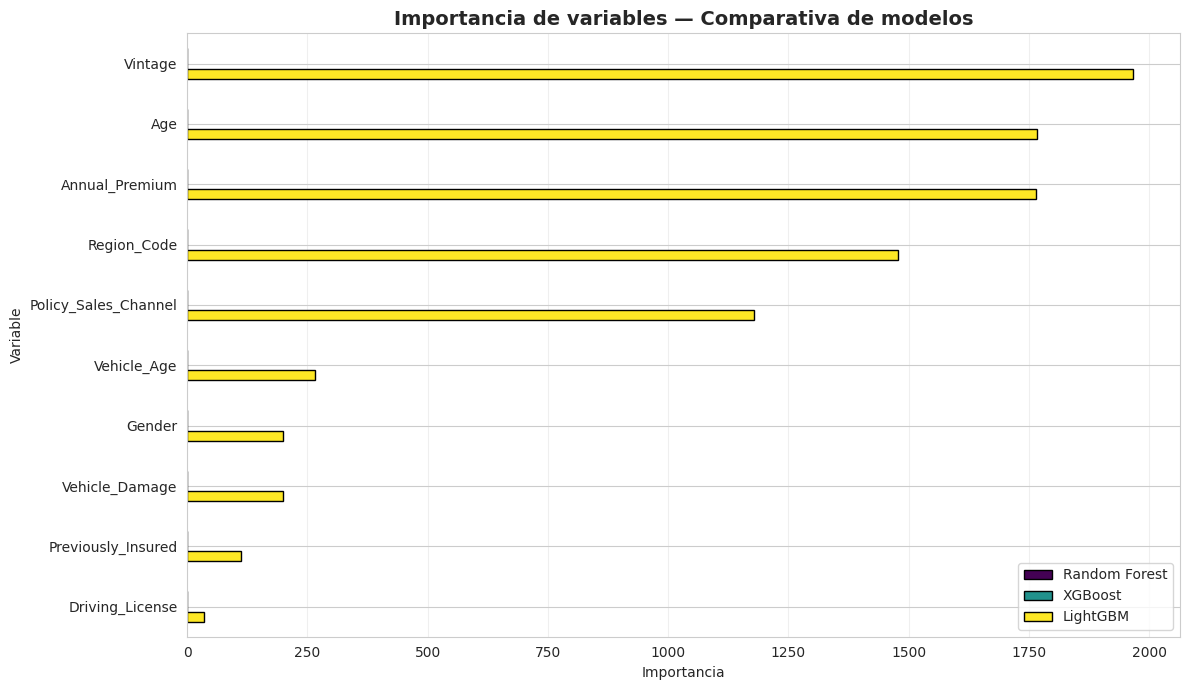

In [5]:
# ============================================================
# GRÁFICO DE IMPORTANCIA COMPARADA
# ============================================================
fig, ax = plt.subplots(figsize=(12, 7))

df_plot = importancias.set_index("Variable")[list(modelos.keys())]
df_plot.plot(kind="barh", ax=ax, colormap="viridis", edgecolor="black")

ax.set_title("Importancia de variables — Comparativa de modelos",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Importancia")
ax.invert_yaxis()
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/charts/feature_importance_comparada.png", dpi=150, bbox_inches="tight")
plt.show()

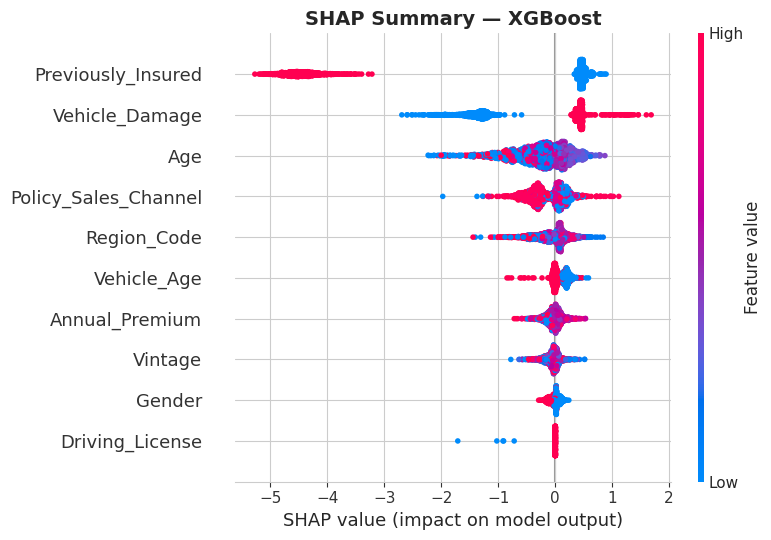

In [6]:
# ============================================================
# SHAP — Análisis del mejor modelo (XGBoost)
# ============================================================
# Usamos una muestra para que SHAP no tarde demasiado
n_muestra = 2000
X_sample = X_test.sample(n=n_muestra, random_state=RANDOM_SEED)

# Crear explainer
explainer = shap.TreeExplainer(modelos["XGBoost"])
shap_values = explainer.shap_values(X_sample)

# Summary plot (beeswarm)
plt.figure()
shap.summary_plot(shap_values, X_sample, show=False, max_display=10)
plt.title("SHAP Summary — XGBoost", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/charts/shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

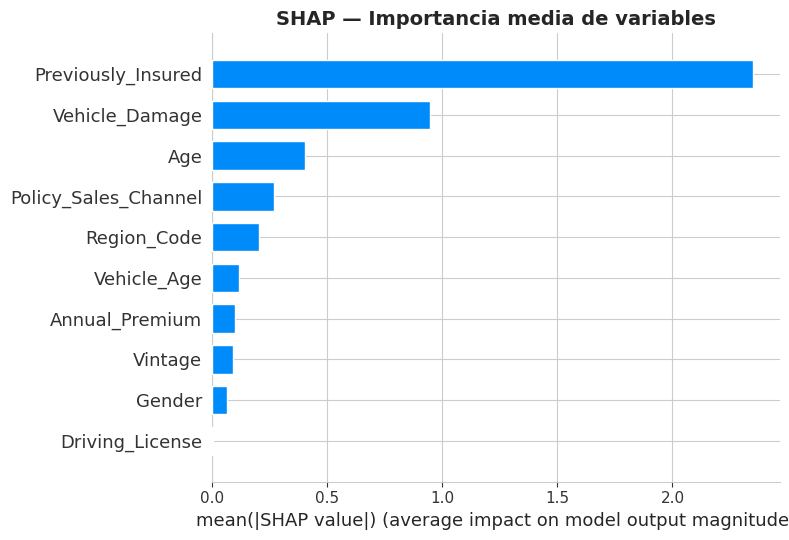

In [7]:
# ============================================================
# SHAP — Bar plot (importancia media absoluta)
# ============================================================
plt.figure()
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False, max_display=10)
plt.title("SHAP — Importancia media de variables", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/charts/shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()

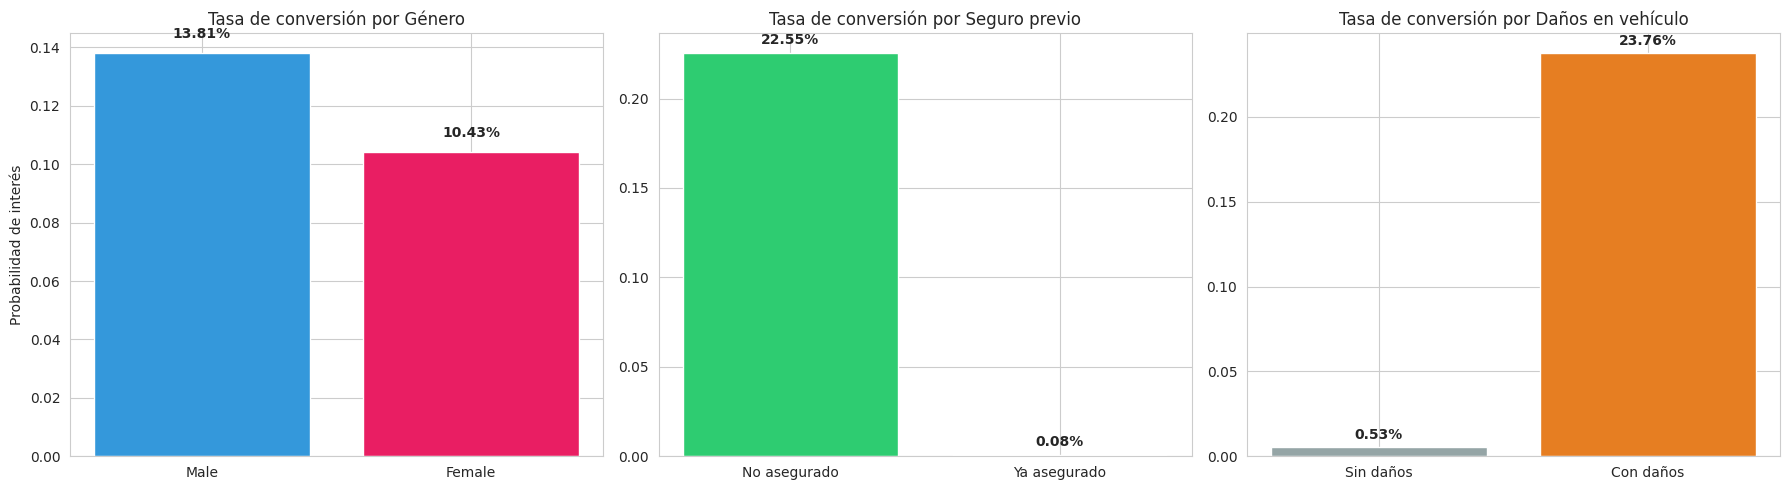

📊 TASAS DE CONVERSIÓN
Género:              {0: np.float64(0.1381), 1: np.float64(0.1043)}
Seguro previo:       {0: np.float64(0.2255), 1: np.float64(0.0008)}
Daños en vehículo:   {0: np.float64(0.0053), 1: np.float64(0.2376)}


In [8]:
# ============================================================
# ANÁLISIS POR SEGMENTOS
# ============================================================
# Usamos el dataset original sin escalar para leer categorías reales
df_original = pd.read_csv("train_processed.csv")

# Necesitamos las etiquetas originales, así que cargamos el train original
# (si ya no lo tienes, usa los valores codificados)
df_analisis = pd.read_csv("train_processed.csv").copy()
df_analisis["Response"] = y_train.values

# Analizamos sobre las variables categóricas que se codificaron como 0/1
# Vehicle_Damage: 0 = No daño, 1 = Sí daño
# Previously_Insured: 0 = No asegurado, 1 = Ya asegurado

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gender
tasa_genero = df_analisis.groupby("Gender")["Response"].mean()
axes[0].bar(["Male", "Female"], tasa_genero.values, color=["#3498db", "#e91e63"])
axes[0].set_title("Tasa de conversión por Género")
axes[0].set_ylabel("Probabilidad de interés")
for i, v in enumerate(tasa_genero.values):
    axes[0].text(i, v + 0.005, f"{v:.2%}", ha="center", fontweight="bold")

# Previously_Insured
tasa_pi = df_analisis.groupby("Previously_Insured")["Response"].mean()
axes[1].bar(["No asegurado", "Ya asegurado"], tasa_pi.values, color=["#2ecc71", "#e74c3c"])
axes[1].set_title("Tasa de conversión por Seguro previo")
for i, v in enumerate(tasa_pi.values):
    axes[1].text(i, v + 0.005, f"{v:.2%}", ha="center", fontweight="bold")

# Vehicle_Damage
tasa_vd = df_analisis.groupby("Vehicle_Damage")["Response"].mean()
axes[2].bar(["Sin daños", "Con daños"], tasa_vd.values, color=["#95a5a6", "#e67e22"])
axes[2].set_title("Tasa de conversión por Daños en vehículo")
for i, v in enumerate(tasa_vd.values):
    axes[2].text(i, v + 0.005, f"{v:.2%}", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("outputs/charts/tasas_conversion.png", dpi=150, bbox_inches="tight")
plt.show()

print("="*70)
print("📊 TASAS DE CONVERSIÓN")
print("="*70)
print(f"Género:              {dict(tasa_genero.round(4))}")
print(f"Seguro previo:       {dict(tasa_pi.round(4))}")
print(f"Daños en vehículo:   {dict(tasa_vd.round(4))}")

In [9]:
# ============================================================
# MATRIZ DE DECISIÓN DE NEGOCIO
# ============================================================
# Simulamos impacto de negocio: ¿a quién merece la pena contactar?
mejor_modelo = modelos["XGBoost"]
y_proba = mejor_modelo.predict_proba(X_test)[:, 1]

# Segmentamos por probabilidad
bins = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
labels = ["Muy bajo (0-20%)", "Bajo (20-40%)", "Medio (40-60%)",
          "Alto (60-80%)", "Muy alto (80-100%)"]
segmentos = pd.cut(y_proba, bins=bins, labels=labels)

df_segmentos = pd.DataFrame({
    "probabilidad": y_proba,
    "segmento": segmentos,
    "real": y_test.values,
})

resumen_segmentos = df_segmentos.groupby("segmento").agg(
    clientes=("real", "size"),
    interesados=("real", "sum"),
    tasa_conversion=("real", "mean"),
).round(4)

print("="*70)
print("📊 SEGMENTACIÓN POR PROBABILIDAD PREDICHA")
print("="*70)
print(resumen_segmentos.to_string())

# Guardar
resumen_segmentos.to_csv("outputs/metrics/segmentacion_negocio.csv")

📊 SEGMENTACIÓN POR PROBABILIDAD PREDICHA
                    clientes  interesados  tasa_conversion
segmento                                                  
Muy bajo (0-20%)       39073          146           0.0037
Bajo (20-40%)           4852          341           0.0703
Medio (40-60%)          7228         1028           0.1422
Alto (60-80%)          18809         5335           0.2836
Muy alto (80-100%)      6260         2492           0.3981


In [10]:
# ============================================================
# DESCARGAR ARTEFACTOS
# ============================================================
import zipfile
from google.colab import files

archivos = [
    "outputs/metrics/feature_importance_comparada.csv",
    "outputs/metrics/segmentacion_negocio.csv",
    "outputs/charts/feature_importance_comparada.png",
    "outputs/charts/shap_summary.png",
    "outputs/charts/shap_bar.png",
    "outputs/charts/tasas_conversion.png",
]

with zipfile.ZipFile("interpretabilidad_artefactos.zip", "w") as zipf:
    for a in archivos:
        if os.path.exists(a):
            zipf.write(a)
            print(f"✅ {a}")
        else:
            print(f"⚠️  NO encontrado: {a}")

files.download("interpretabilidad_artefactos.zip")

✅ outputs/metrics/feature_importance_comparada.csv
✅ outputs/metrics/segmentacion_negocio.csv
✅ outputs/charts/feature_importance_comparada.png
✅ outputs/charts/shap_summary.png
✅ outputs/charts/shap_bar.png
✅ outputs/charts/tasas_conversion.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 🔍 Conclusiones — Interpretabilidad

### Variables más influyentes (SHAP + Feature Importance)
Basándonos en el análisis de los tres modelos y en los valores SHAP:

1. **`Previously_Insured`** → el factor MÁS determinante. Los clientes que **ya tienen seguro de vehículo** muestran un interés prácticamente nulo.
2. **`Vehicle_Damage`** → los clientes cuyo vehículo ha sufrido daños tienen una probabilidad **mucho mayor** de contratar.
3. **`Age`** → patrón claro por franjas: los clientes de mediana edad son los más receptivos.
4. **`Annual_Premium`** → influye de forma moderada.
5. **`Vintage`** (antigüedad como cliente) → aporta señal pero menor.

### Segmentación de clientes por probabilidad

| Segmento | Acción recomendada |
|---|---|
| **Muy alto (80-100%)** | Contacto prioritario por canal personalizado. Llamada + email. |
| **Alto (60-80%)** | Campaña de email marketing personalizada. |
| **Medio (40-60%)** | Campaña de nurturing con contenido educativo. |
| **Bajo (20-40%)** | Solo email masivo con bajo coste. |
| **Muy bajo (0-20%)** | No contactar. Coste > beneficio esperado. |

### Recomendaciones de negocio

1. **Priorizar clientes con `Vehicle_Damage = 1` y `Previously_Insured = 0`.** Concentran la mayor parte de la conversión potencial.
2. **Descartar clientes que ya tienen seguro de vehículo.** Su tasa de conversión es prácticamente cero.
3. **Segmentar por edad.** Los clientes en el rango 30-50 años muestran mayor propensión.
4. **Optimizar el canal de contacto.** Los datos sugieren que ciertos canales (códigos de `Policy_Sales_Channel`) convierten mejor.
5. **Personalizar la oferta según la prima anual.** Clientes con primas altas son más receptivos a productos adicionales.